In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3 

In [3]:
#1.importng database

In [4]:
conn = sqlite3.connect(r"C:\Users\User\Downloads\Business Analyst Projects\Project\customer_churn.db")

In [5]:
sql_query=("""
    select name
    from sqlite_master
    where type="table";
""")

In [6]:
tables= pd.read_sql(sql_query, conn)

In [7]:
print(tables)

              name
0      db_customer
1  db_subscription
2       db_support


In [8]:
for table_name in tables['name']:
    df=pd.read_sql(f"select * from {table_name}",conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe:df_{table_name}")

df
conn.close()

Created dataframe:df_db_customer
Created dataframe:df_db_subscription
Created dataframe:df_db_support


In [9]:
# Printing table names and column names
conn = sqlite3.connect(r"C:\Users\User\Downloads\Business Analyst Projects\Project\customer_churn.db")

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [10]:
#1 data cleaning

In [11]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [12]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [13]:
df_db_customer.sample(5)

,customerid,name,country,state,gender,dob,interests,pincode
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
11,0017-IUDMW,rangadevi,India,Karnataka,Female,1981-06-18 00:00:00,NaN,None
13,0019-EFAEP,raju,India,Meghalaya,Female,1992-04-25 00:00:00,NaN,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None


In [14]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [15]:
#a. renaming columns for better identifiaction
#b. dropping unnecessary column
#c. changing datatype in dob column
#d. data standarization in geneder column
#e. fixing missing values in country column


In [16]:
#a. renaming columns for better identification
df_db_customer.rename(columns={'name':'customer_name'})

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00,NaN,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00,NaN,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,None


In [17]:
#to fix the new name of name column 

df_db_customer.rename(columns={'name':'customer_name'},inplace=True)

In [18]:
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00,NaN,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00,NaN,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,None


In [19]:
#b. dropping unnecessary column
#df_db_customer.drop(df_db_customer.columns[-2:],axis=1)

df_db_customer.drop(columns=['interests','pincode'],inplace=True)

In [20]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [21]:
#c. changing datatype in dob column

#pd.to_datetime(df_db_customer['dob'])
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])


In [22]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [23]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        18 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.1 KB


In [24]:
#to check which values are there in gender 
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female', 'Women', 'Men']
Length: 4, dtype: str

In [25]:
#d. data standarization in geneder column
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})

In [26]:
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [27]:
#e.fixing missing values

In [28]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        18 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.1 KB


In [29]:
df_db_customer['country'].isna()

0     False
1     False
2     False
3     False
4     False
5      True
6     False
7     False
8      True
9     False
10    False
11    False
12     True
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
Name: country, dtype: bool

In [30]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [31]:
#df_db_customer['country'].fillna('Unknown')
# but here as we can actually fill the null country info from existing data

In [32]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,NaN,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,NaN,Kathmandu
9,Nepal,Kathmandu


In [33]:
#mapping state with country
state_country_pair = df_db_customer.set_index('state')['country'].to_dict()

state_country_pair

{'Maharashtra': 'India',
 'Karnataka': 'India',
 'Delhi': 'India',
 'Nagaland': 'India',
 'Meghalaya': 'India',
 'Rajasthan': 'India',
 'Kathmandu': 'Nepal',
 'Telangana': 'India',
 'Uttar Pradesh': 'India'}

In [34]:
df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_pair))

0     India
1     India
2     India
3     India
4     India
5     India
6     India
7     India
8     Nepal
9     Nepal
10    India
11    India
12    India
13    India
14    India
15    India
16    India
17    India
18    India
19    India
20    India
Name: country, dtype: str

In [35]:
df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_pair))

In [36]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [37]:
#subscription table data cleaning 

In [38]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [39]:
df_db_subscription.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,NaN,NaN,20.99,550,62
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,NaN,NaN,13.99,840,27
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,99
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,NaN,NaN,22.99,1955,7
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,NaN,NaN,13.99,790,47


In [40]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [41]:
date_col=['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [42]:
#table df_db_support

In [43]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [44]:
df_db_support.tail()

,customerid,complaint_date,escalations,csat_score,col_1,comment
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,NaN
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,NaN
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,NaN
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund


In [45]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [46]:
#b. dropping unnecessary column

df_db_support.drop(columns= ['col_1','comment'],inplace=True)

In [47]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customerid      9 non-null      str  
 1   complaint_date  9 non-null      str  
 2   escalations     9 non-null      str  
 3   csat_score      9 non-null      int64
dtypes: int64(1), str(3)
memory usage: 420.0 bytes


In [48]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])

df_db_support['complaint_date']

0   2024-08-28
1   2024-08-28
2   2024-01-20
3   2025-03-18
4   2024-11-01
5   2024-04-10
6   2024-09-27
7   2024-09-13
8   2024-09-14
Name: complaint_date, dtype: datetime64[us]

In [49]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [50]:
#feature engineering and data analysis

In [51]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [52]:
#np.where(df_db_subscription['cancellation_date'].notna(),1,0)
#creating a new column ['churn_flag'] under df_db_subscription table using an existing column

df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [53]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [54]:
df_db_subscription.shape

(21, 12)

In [55]:
df=(df_db_subscription
    .merge(df_db_customer, on='customerid',how='left')
    .merge(df_db_support, on='customerid',how='left') )     

In [56]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN


In [57]:
df.shape

(23, 20)

In [58]:
df_db_subscription.shape

(21, 12)

In [59]:
df_db_support.shape

(9, 4)

In [60]:
df_db_customer.shape

(21, 6)

In [61]:
df_db_subscription['customerid'].nunique()

21

In [62]:
df_db_customer['customerid'].nunique()

21

In [63]:
df_db_support['customerid'].nunique()

7

In [64]:
df_db_support['customerid'].size

9

In [65]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30


In [66]:
df_db_support.groupby('customerid')['customerid'].transform('count')

0    2
1    2
2    1
3    1
4    1
5    1
6    1
7    2
8    2
Name: customerid, dtype: int64

In [67]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [68]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1


In [69]:
#df_db_support.sort_values(by='complaint_date')
df_db_support.sort_values('complaint_date')

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [70]:
df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [71]:
df_db_support.shape

(9, 5)

In [72]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')


In [73]:
df_db_support.shape

(7, 5)

In [74]:
df=(df_db_subscription
    .merge(df_db_customer, on='customerid',how='left')
    .merge(df_db_support, on='customerid',how='left') ) 

In [75]:
df.shape

(21, 21)

In [76]:
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,...,0,durga,India,Delhi,Female,1988-12-10,2025-03-18,N,90.0,1.0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,1,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0,1.0
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,...,0,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN,NaN
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,...,0,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN,NaN
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,...,0,arjun,Nepal,Kathmandu,Male,1993-10-29,NaT,NaN,NaN,NaN


In [77]:
#df_db_customer.shape
#df_db_support.shape
df_db_subscription.shape

(21, 12)

In [78]:
df['customerid'].unique()

<StringArray>
['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ',
 '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS',
 '0017-DINOC', '0017-IUDMW', '0018-NYROU', '0019-EFAEP', '0019-GFNTW',
 '0020-INWCK', '0020-JDNXP', '0021-IKXGC', '0022-TCJCI', '0023-HGHWL',
 '0023-UYUPN']
Length: 21, dtype: str

In [79]:
df=(df_db_subscription
    .merge(df_db_customer, on='customerid',how='left')
    .merge(df_db_support, on='customerid',how='left') ) 

In [80]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0


In [81]:
df.shape

(21, 21)

In [82]:
df.columns.tolist()

['customerid',
 'subscription_start_date',
 'subscription_type',
 'renewal_date',
 'plan_type',
 'contract_type',
 'cancellation_date',
 'cancellation_reason',
 'monthly_charges',
 'cltv',
 'churn_score',
 'churn_flag',
 'customer_name',
 'country',
 'state',
 'gender',
 'dob',
 'complaint_date',
 'escalations',
 'csat_score',
 'complaint_count']

In [83]:
df.shape

(21, 21)

In [84]:
df.to_csv('exported_churn_data.csv', index=False)

In [85]:
# Data Analysis

In [86]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [87]:
df.columns.tolist()

['customerid',
 'subscription_start_date',
 'subscription_type',
 'renewal_date',
 'plan_type',
 'contract_type',
 'cancellation_date',
 'cancellation_reason',
 'monthly_charges',
 'cltv',
 'churn_score',
 'churn_flag',
 'customer_name',
 'country',
 'state',
 'gender',
 'dob',
 'complaint_date',
 'escalations',
 'csat_score',
 'complaint_count']

In [88]:
#churn:
df['churn_flag'].mean()

np.float64(0.2857142857142857)

In [89]:
#churn_rate

churn_rate=df['churn_flag'].mean()*100
print("Churn Rate:",churn_rate)
print("Churn Rate:",round(churn_rate,2),"%")

Churn Rate: 28.57142857142857
Churn Rate: 28.57 %


In [90]:
#retention rate 

retention_rate=100-churn_rate
print("Retention Rate:",retention_rate)
print("Retention Rate:",round(retention_rate,2),"%")

Retention Rate: 71.42857142857143
Retention Rate: 71.43 %


In [91]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


In [92]:
#churn by plan type
df.groupby('plan_type')['churn_flag'].mean() 

plan_type
Basic       0.600000
Premium     0.142857
Standard    0.222222
Name: churn_flag, dtype: float64

In [93]:
churn_by_plan =(df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2))
print("churn_by_plan:",churn_by_plan)   


churn_by_plan: plan_type
Basic       60.00
Premium     14.29
Standard    22.22
Name: churn_flag, dtype: float64


In [94]:
churn_by_plan =(df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_percentage'))
print(churn_by_plan)   

  plan_type  churn_rate_percentage
0     Basic                  60.00
1   Premium                  14.29
2  Standard                  22.22


In [95]:
#churn by state +sum(revenue) & count of users

#df.groupby('state')['churn_flag'].mean()

# churn_by_state=(df.groupby('state')['churn_flag'].mean().mul(100).round(2))
# print(churn_by_state)

churn_rate_by_state=(df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name="churn_rate_by_state"))
print(churn_rate_by_state)


           state  churn_rate_by_state
0          Delhi                25.00
1      Karnataka               100.00
2      Kathmandu                 0.00
3    Maharashtra                 0.00
4      Meghalaya                66.67
5       Nagaland                 0.00
6      Rajasthan                 0.00
7      Telangana                50.00
8  Uttar Pradesh                 0.00


In [96]:
#sum(revenue) statewise
statewise_sum_revenue=(df.groupby('state')['cltv'].sum().reset_index(name='statewise_sum_revenue'))
print(statewise_sum_revenue)

           state  statewise_sum_revenue
0          Delhi                   1765
1      Karnataka                   1420
2      Kathmandu                    575
3    Maharashtra                   3027
4      Meghalaya                    940
5       Nagaland                   1725
6      Rajasthan                   2680
7      Telangana                   1022
8  Uttar Pradesh                   4140


In [97]:
#count of users statewise
statewise_user_count=(df.groupby('state')['customerid'].count().reset_index(name='statewise_user_count'))
print(statewise_user_count)

           state  statewise_user_count
0          Delhi                     4
1      Karnataka                     2
2      Kathmandu                     2
3    Maharashtra                     3
4      Meghalaya                     3
5       Nagaland                     1
6      Rajasthan                     2
7      Telangana                     2
8  Uttar Pradesh                     2


In [98]:
# wrong 
print(churn_rate_by_state,statewise_sum_revenue,statewise_user_count)

           state  churn_rate_by_state
0          Delhi                25.00
1      Karnataka               100.00
2      Kathmandu                 0.00
3    Maharashtra                 0.00
4      Meghalaya                66.67
5       Nagaland                 0.00
6      Rajasthan                 0.00
7      Telangana                50.00
8  Uttar Pradesh                 0.00            state  statewise_sum_revenue
0          Delhi                   1765
1      Karnataka                   1420
2      Kathmandu                    575
3    Maharashtra                   3027
4      Meghalaya                    940
5       Nagaland                   1725
6      Rajasthan                   2680
7      Telangana                   1022
8  Uttar Pradesh                   4140            state  statewise_user_count
0          Delhi                     4
1      Karnataka                     2
2      Kathmandu                     2
3    Maharashtra                     3
4      Meghalaya         

In [99]:
#wrong 
pd.concat([churn_rate_by_state,statewise_sum_revenue,statewise_user_count],axis=1)

,state,churn_rate_by_state,state,statewise_sum_revenue,state,statewise_user_count
0,Delhi,25.00,Delhi,1765,Delhi,4
1,Karnataka,100.00,Karnataka,1420,Karnataka,2
2,Kathmandu,0.00,Kathmandu,575,Kathmandu,2
3,Maharashtra,0.00,Maharashtra,3027,Maharashtra,3
4,Meghalaya,66.67,Meghalaya,940,Meghalaya,3
5,Nagaland,0.00,Nagaland,1725,Nagaland,1
6,Rajasthan,0.00,Rajasthan,2680,Rajasthan,2
7,Telangana,50.00,Telangana,1022,Telangana,2
8,Uttar Pradesh,0.00,Uttar Pradesh,4140,Uttar Pradesh,2


In [100]:
# statewise_analysis=churn_rate_by_state
#                     .merge(statewise_sum_revenue, on ='state')
#                     .merge(statewise_user_count,on ='state')
statewise_analysis = churn_rate_by_state.merge(statewise_sum_revenue, on='state').merge(statewise_user_count,on='state')

print(statewise_analysis)

           state  churn_rate_by_state  statewise_sum_revenue  \
0          Delhi                25.00                   1765   
1      Karnataka               100.00                   1420   
2      Kathmandu                 0.00                    575   
3    Maharashtra                 0.00                   3027   
4      Meghalaya                66.67                    940   
5       Nagaland                 0.00                   1725   
6      Rajasthan                 0.00                   2680   
7      Telangana                50.00                   1022   
8  Uttar Pradesh                 0.00                   4140   

   statewise_user_count  
0                     4  
1                     2  
2                     2  
3                     3  
4                     3  
5                     1  
6                     2  
7                     2  
8                     2  


In [101]:
print(statewise_analysis[ ['state','churn_rate_by_state','statewise_sum_revenue','statewise_user_count']])

           state  churn_rate_by_state  statewise_sum_revenue  \
0          Delhi                25.00                   1765   
1      Karnataka               100.00                   1420   
2      Kathmandu                 0.00                    575   
3    Maharashtra                 0.00                   3027   
4      Meghalaya                66.67                    940   
5       Nagaland                 0.00                   1725   
6      Rajasthan                 0.00                   2680   
7      Telangana                50.00                   1022   
8  Uttar Pradesh                 0.00                   4140   

   statewise_user_count  
0                     4  
1                     2  
2                     2  
3                     3  
4                     3  
5                     1  
6                     2  
7                     2  
8                     2  


In [102]:
#churn by subscription type +sum(revenue) & count of users

churn_rate_by_subscription_type=df.groupby('subscription_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_by_subscription_type')

print(churn_rate_by_subscription_type)


  subscription_type  churn_rate_by_subscription_type
0           Organic                             0.00
1              Paid                            16.67
2          Refferal                            83.33


In [103]:

sum_by_subscription_type=df.groupby('subscription_type')['cltv'].sum().reset_index(name='sum_by_subscription_type')

print(sum_by_subscription_type)


  subscription_type  sum_by_subscription_type
0           Organic                      8360
1              Paid                      7410
2          Refferal                      1524


In [104]:
count_by_subscription_type=df.groupby('subscription_type')['customerid'].count().reset_index(name='count_by_subscription_type')

print(count_by_subscription_type)


  subscription_type  count_by_subscription_type
0           Organic                           9
1              Paid                           6
2          Refferal                           6


In [105]:
df.shape

(21, 21)

In [106]:
analysis_on_subscription_type = (churn_rate_by_subscription_type
                        .merge(sum_by_subscription_type, on='subscription_type')
                        .merge(count_by_subscription_type,on='subscription_type'))

print(analysis_on_subscription_type)

  subscription_type  churn_rate_by_subscription_type  \
0           Organic                             0.00   
1              Paid                            16.67   
2          Refferal                            83.33   

   sum_by_subscription_type  count_by_subscription_type  
0                      8360                           9  
1                      7410                           6  
2                      1524                           6  


In [107]:
print(analysis_on_subscription_type[['subscription_type','churn_rate_by_subscription_type','sum_by_subscription_type','count_by_subscription_type']])

  subscription_type  churn_rate_by_subscription_type  \
0           Organic                             0.00   
1              Paid                            16.67   
2          Refferal                            83.33   

   sum_by_subscription_type  count_by_subscription_type  
0                      8360                           9  
1                      7410                           6  
2                      1524                           6  


In [108]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [109]:
#ARPU : Average Revenue per User

Average_Revenue_per_User=df['monthly_charges'].mean()
print('Average_Revenue_per_User/ARPU:',round(Average_Revenue_per_User,2))

Average_Revenue_per_User/ARPU: 18.85


In [110]:
#calculate customer age

df['dob'] = pd.to_datetime(df['dob'])

age=(pd.Timestamp.today()- df['dob'])
print(age)
# print(df['customerid',age])

0    16209 days 07:30:28.899595
1    11236 days 07:30:28.899595
2    17726 days 07:30:28.899595
3     9129 days 07:30:28.899595
4    13264 days 07:30:28.899595
5    13775 days 07:30:28.899595
6    18238 days 07:30:28.899595
7    10029 days 07:30:28.899595
8    15027 days 07:30:28.899595
9    11991 days 07:30:28.899595
10   10810 days 07:30:28.899595
11   16507 days 07:30:28.899595
12    7940 days 07:30:28.899595
13   12543 days 07:30:28.899595
14   17092 days 07:30:28.899595
15   14791 days 07:30:28.899595
16   11697 days 07:30:28.899595
17    9491 days 07:30:28.899595
18   15582 days 07:30:28.899595
19   12890 days 07:30:28.899595
20   17858 days 07:30:28.899595
Name: dob, dtype: timedelta64[us]


In [111]:
#age=(pd.Timestamp.today()-df['dob']) #days
age=(pd.Timestamp.today()-df['dob']).dt.days//365  #years
print(age)

0     44
1     30
2     48
3     25
4     36
5     37
6     49
7     27
8     41
9     32
10    29
11    45
12    21
13    34
14    46
15    40
16    32
17    26
18    42
19    35
20    48
Name: dob, dtype: int64


In [112]:
df['age']=(pd.Timestamp.today()-df['dob']).dt.days//365 
df.head()
print(df[['customerid','age']])

    customerid  age
0   0002-ORFBO   44
1   0003-MKNFE   30
2   0004-TLHLJ   48
3   0011-IGKFF   25
4   0013-EXCHZ   36
5   0013-MHZWF   37
6   0013-SMEOE   49
7   0014-BMAQU   27
8   0015-UOCOJ   41
9   0016-QLJIS   32
10  0017-DINOC   29
11  0017-IUDMW   45
12  0018-NYROU   21
13  0019-EFAEP   34
14  0019-GFNTW   46
15  0020-INWCK   40
16  0020-JDNXP   32
17  0021-IKXGC   26
18  0022-TCJCI   42
19  0023-HGHWL   35
20  0023-UYUPN   48


In [113]:
today = pd.Timestamp.today()

df['age'] = (
    today.year - df['dob'].dt.year)
 
print(df[['customerid', 'age']])

    customerid  age
0   0002-ORFBO   44
1   0003-MKNFE   31
2   0004-TLHLJ   48
3   0011-IGKFF   25
4   0013-EXCHZ   36
5   0013-MHZWF   38
6   0013-SMEOE   50
7   0014-BMAQU   27
8   0015-UOCOJ   41
9   0016-QLJIS   33
10  0017-DINOC   29
11  0017-IUDMW   45
12  0018-NYROU   22
13  0019-EFAEP   34
14  0019-GFNTW   47
15  0020-INWCK   40
16  0020-JDNXP   32
17  0021-IKXGC   26
18  0022-TCJCI   43
19  0023-HGHWL   35
20  0023-UYUPN   49


In [114]:
today = pd.Timestamp.today()

df['age'] = (
    today.year - df['dob'].dt.year
    - (
        (today.month < df['dob'].dt.month) |
        ((today.month == df['dob'].dt.month) & 
         (today.day < df['dob'].dt.day))
    )
)

print(df[['customerid', 'age']])

    customerid  age
0   0002-ORFBO   44
1   0003-MKNFE   30
2   0004-TLHLJ   48
3   0011-IGKFF   24
4   0013-EXCHZ   36
5   0013-MHZWF   37
6   0013-SMEOE   49
7   0014-BMAQU   27
8   0015-UOCOJ   41
9   0016-QLJIS   32
10  0017-DINOC   29
11  0017-IUDMW   45
12  0018-NYROU   21
13  0019-EFAEP   34
14  0019-GFNTW   46
15  0020-INWCK   40
16  0020-JDNXP   32
17  0021-IKXGC   25
18  0022-TCJCI   42
19  0023-HGHWL   35
20  0023-UYUPN   48


In [115]:
#Average Customer Tenure
#if cancellation day is not available we will use today's date

today= pd.Timestamp.today()

df['active_customer']=np.where(df['cancellation_date'].notna(),0,1)
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,age,active_customer
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,44,1
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,30,0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,48,1
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,24,1
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0,36,0


In [116]:
print(df['active_customer'].count()) #wrong

21


In [117]:
print(df['active_customer'].sum()) #no.of active users/customers

15


In [118]:
#Average Customer Tenure

# Convert date columns to datetime first
df['cancellation_date'] = pd.to_datetime(df['cancellation_date'], errors='coerce')
df['subscription_start_date'] = pd.to_datetime(df['subscription_start_date'], errors='coerce')

#df['t']=np.where(df['active_customer']==1,'t', 'na')

df['tenure_days']=np.where(df['cancellation_date'].notna(),
                           (df['cancellation_date'] - df['subscription_start_date']).dt.days,    
                           (today - df['subscription_start_date']).dt.days)
# today= pd.Timestamp.today()
# df['tenure_days']=np.where(df['active_customer']==0,
#                            (df['cancellation_date'] - df['subscription_start_date']).dt.days,    
#                            (today - df['subscription_start_date']).dt.days)


df.head() 


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,age,active_customer,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,44,1,1992.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,30,0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,48,1,1377.0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,24,1,2667.0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0,36,0,419.0


In [119]:
avg_tenure_days=df['tenure_days'].mean()
print('avg_tenure_days=',round(avg_tenure_days,0))

avg_tenure_days= 1527.0


In [120]:
today-pd.Timestamp('2026-02-28')  #random

Timedelta('181 days 07:30:29.288271')

In [121]:

df.loc[df['churn_flag']==1,'monthly_charges']


1     12.99
4     13.99
6      8.99
11     7.99
13    12.99
18    16.99
Name: monthly_charges, dtype: float64

In [122]:
#revenue at risk - revenue lost from churned users

revenue_at_risk=df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print('revenue_at_risk, Rs. in lakhs:',revenue_at_risk)

revenue_at_risk, Rs. in lakhs: 73.94


In [123]:
df.loc[df['churn_flag']==1,'monthly_charges'].count() # number of churned customers

np.int64(6)

In [124]:
df.loc[df['churn_flag']==1,'monthly_charges'].mean()  #average monthly charge of churned customers

np.float64(12.323333333333332)

In [125]:
#Escalation rate

Escalation_rate=(df['escalations']== 'Y').mean()*100

print('Escalation rate=',Escalation_rate.round(2))


Escalation rate= 19.05


In [126]:
df['escalations'].unique()

<StringArray>
[nan, 'Y', 'N']
Length: 3, dtype: str

In [127]:
# total count of complaints

total_complaint_count=df['complaint_count'].sum()
print('total_complaint_count',total_complaint_count)

total_complaint_count 9.0


In [128]:
#avg count of complaints

avg_complaint_count=df['complaint_count'].sum()/ df['customerid'].count()
print('avg_complaint_count',avg_complaint_count)

avg_complaint_count 0.42857142857142855


In [129]:
#avg count of complaints

avgcomplaint_count=df['complaint_count'].sum()/ df['customerid'].nunique()
print('avgcomplaint_count',avgcomplaint_count)

avgcomplaint_count 0.42857142857142855


In [130]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,age,active_customer,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,44,1,1992.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,30,0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,48,1,1377.0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,24,1,2667.0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0,36,0,419.0


In [131]:
# Correlation Escalation vs churn

#df[['customerid','escalations','churn_flag']]
#corr_escalation-churn=df[['customerid','escalations','churn_flag']].dropna()

df['Escalation']=np.where(df['escalations']=='Y',1,0) #encoding string to int type (put the int to another column here)
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,gender,dob,complaint_date,escalations,csat_score,complaint_count,age,active_customer,tenure_days,Escalation
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,Male,1982-04-12,NaT,NaN,NaN,NaN,44,1,1992.0,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Male,1995-11-23,2024-08-28,Y,10.0,2.0,30,0,1501.0,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,Female,1978-02-15,NaT,NaN,NaN,NaN,48,1,1377.0,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,Male,2001-08-30,NaT,NaN,NaN,NaN,24,1,2667.0,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Female,1990-05-05,2024-01-20,Y,20.0,1.0,36,0,419.0,1


In [132]:
corr_escalation_churn=df[['customerid','escalations','Escalation','churn_flag']].dropna()
print(corr_escalation_churn)

    customerid escalations  Escalation  churn_flag
1   0003-MKNFE           Y           1           1
4   0013-EXCHZ           Y           1           1
5   0013-MHZWF           N           0           0
6   0013-SMEOE           N           0           1
11  0017-IUDMW           Y           1           1
13  0019-EFAEP           Y           1           1
18  0022-TCJCI           N           0           1


In [133]:
correlation= corr_escalation_churn['Escalation'].corr(df['churn_flag'])

print(correlation)

0.4714045207910318


In [134]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'age',
       'active_customer', 'tenure_days', 'Escalation'],
      dtype='str')

In [135]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,gender,dob,complaint_date,escalations,csat_score,complaint_count,age,active_customer,tenure_days,Escalation
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,Male,1982-04-12,NaT,NaN,NaN,NaN,44,1,1992.0,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Male,1995-11-23,2024-08-28,Y,10.0,2.0,30,0,1501.0,1


In [136]:
## churn risk- 

conditions= [
    (df['churn_score']<50),
      (df['churn_score']>=50) &   (df['churn_score']<70),
      (df['churn_score']>=70)
]

choices=['low','mdium','high']

df['churn_risk']=np.select(conditions,choices,default='unknown')

print(df['churn_risk'])

0       low
1      high
2       low
3       low
4      high
5       low
6      high
7       low
8       low
9       low
10      low
11     high
12      low
13     high
14      low
15    mdium
16    mdium
17      low
18     high
19      low
20      low
Name: churn_risk, dtype: str


In [137]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,dob,complaint_date,escalations,csat_score,complaint_count,age,active_customer,tenure_days,Escalation,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,1982-04-12,NaT,NaN,NaN,NaN,44,1,1992.0,0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1995-11-23,2024-08-28,Y,10.0,2.0,30,0,1501.0,1,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,1978-02-15,NaT,NaN,NaN,NaN,48,1,1377.0,0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,2001-08-30,NaT,NaN,NaN,NaN,24,1,2667.0,0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1990-05-05,2024-01-20,Y,20.0,1.0,36,0,419.0,1,high


In [138]:
df[['churn_score','churn_risk']]

,churn_score,churn_risk
0,12,low
1,91,high
2,34,low
3,8,low
4,88,high
5,22,low
6,79,high
7,5,low
8,34,low
9,41,low


In [139]:
#Visualization using matplotlib

In [140]:
df_visual=df.copy()

In [141]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'age',
       'active_customer', 'tenure_days', 'Escalation', 'churn_risk'],
      dtype='str')

In [142]:
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,dob,complaint_date,escalations,csat_score,complaint_count,age,active_customer,tenure_days,Escalation,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,1982-04-12,NaT,NaN,NaN,NaN,44,1,1992.0,0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1995-11-23,2024-08-28,Y,10.0,2.0,30,0,1501.0,1,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,1978-02-15,NaT,NaN,NaN,NaN,48,1,1377.0,0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,2001-08-30,NaT,NaN,NaN,NaN,24,1,2667.0,0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1990-05-05,2024-01-20,Y,20.0,1.0,36,0,419.0,1,high


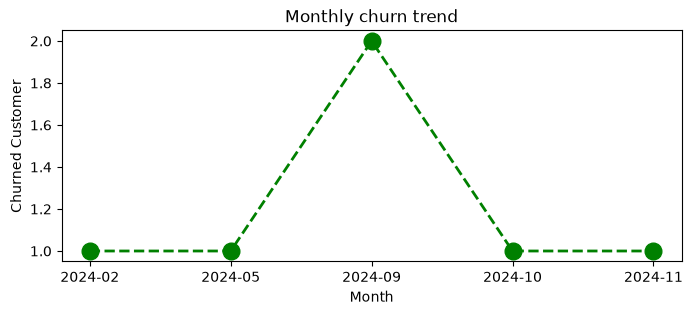

In [143]:
# monthly churn trend ( Time Series KPI)

#df_visual['cancellation_date'].dt.to_period('M')

df_visual['cancellation_month']=df_visual['cancellation_date'].dt.to_period('M')
#print(df_visual['cancellation_month'])

monthwise_churn_trend = df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()
#print(churn_trend)

plt.figure(figsize=(8,3))
plt.plot(monthwise_churn_trend.index.astype(str),monthwise_churn_trend.values,color='green', marker='o', linestyle='dashed',
      linewidth=2, markersize=12)
plt.title('Monthly churn trend')
plt.xlabel('Month')
plt.ylabel('Churned Customer')
plt.show()

In [144]:
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,complaint_date,escalations,csat_score,complaint_count,age,active_customer,tenure_days,Escalation,churn_risk,cancellation_month
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,NaT,NaN,NaN,NaN,44,1,1992.0,0,low,NaT
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,2024-08-28,Y,10.0,2.0,30,0,1501.0,1,high,2024-09
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,NaT,NaN,NaN,NaN,48,1,1377.0,0,low,NaT
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,NaT,NaN,NaN,NaN,24,1,2667.0,0,low,NaT
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,2024-01-20,Y,20.0,1.0,36,0,419.0,1,high,2024-02


       cancellation_week  churned count
0  2024-02-26/2024-03-03              1
1  2024-04-29/2024-05-05              1
2  2024-09-09/2024-09-15              2
3  2024-10-28/2024-11-03              1
4  2024-11-11/2024-11-17              1


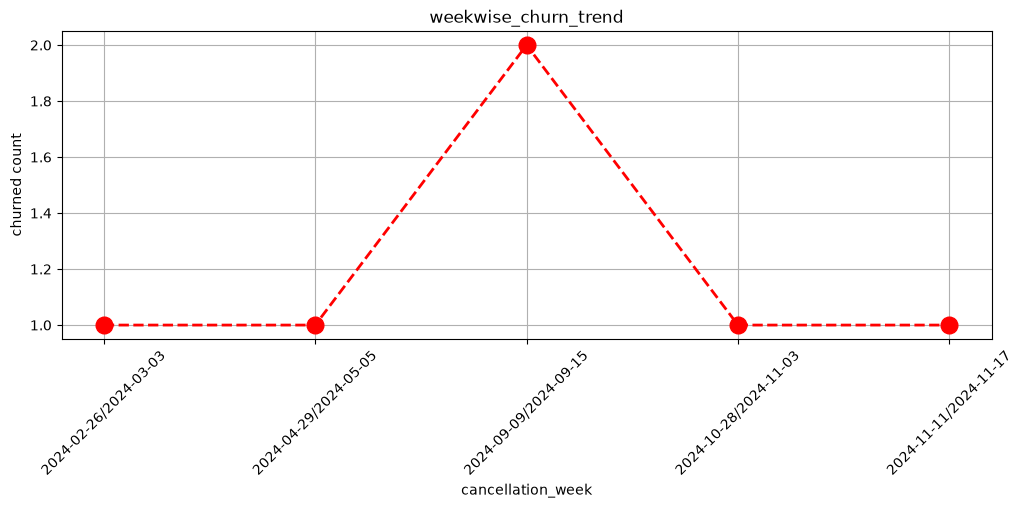

In [145]:
#print(df_visual['cancellation_date'].dtype)

#df_visual['cancellation_date'] = pd.to_datetime(df_visual['cancellation_date'])

#df_visual['cancellation_date'].dt.asfreq('W')


df_visual['cancellation_week'] = df_visual['cancellation_date'].dt.to_period('W')

weekwise_churn_trend = df_visual[df_visual['churn_flag']==1].groupby(df_visual['cancellation_week']).size().reset_index(name='churned count')

print(weekwise_churn_trend)

plt.figure(figsize=(12,4))                
plt.plot(weekwise_churn_trend['cancellation_week'].astype(str), weekwise_churn_trend['churned count'], color='red', marker='o', linestyle='dashed', linewidth=2, markersize=12)
plt.xlabel('cancellation_week')
plt.ylabel('churned count')
plt.title('weekwise_churn_trend')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


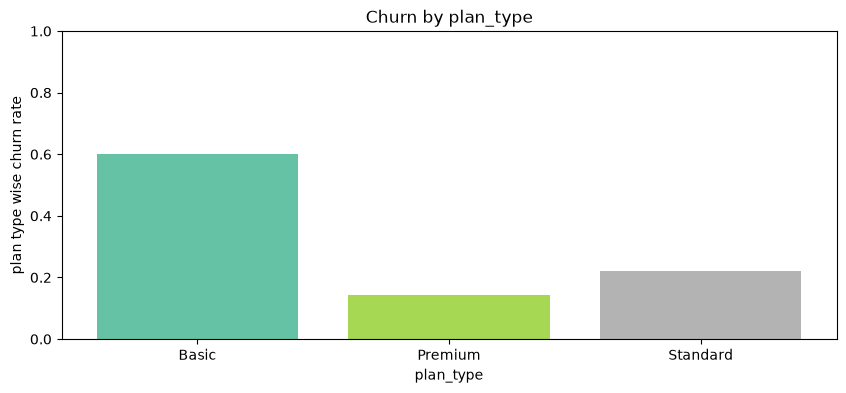

In [146]:
# Churn by plan_type

#df_visual.groupby('plan_type')['churn_flag'].sum().reset_index(name='plantype wise churn count')

Churn_by_plan_type=df_visual.groupby('plan_type')['churn_flag'].mean().reset_index(name='plan type wise churn rate')

colors=plt.cm.Set2(np.linspace(0,1,len(Churn_by_plan_type)))

plt.figure(figsize=(10,4))
#plt.plot(Churn_by_plan_type['plan_type'],Churn_by_plan_type['plan type wise churn rate'],color='blue', marker='o', linestyle='dashed',linewidth=2, markersize=12)
#plt.bar(Churn_by_plan_type['plan_type'],Churn_by_plan_type['plan type wise churn rate'],color='blue')
plt.bar(Churn_by_plan_type['plan_type'],Churn_by_plan_type['plan type wise churn rate'],color=colors)
plt.title('Churn by plan_type')
plt.xlabel('plan_type')
plt.ylabel('plan type wise churn rate')
plt.ylim(0,1)
plt.show()


In [147]:
df_visual[df_visual['churn_flag']==1].groupby('plan_type').size()

plan_type
Basic       3
Premium     1
Standard    2
dtype: int64

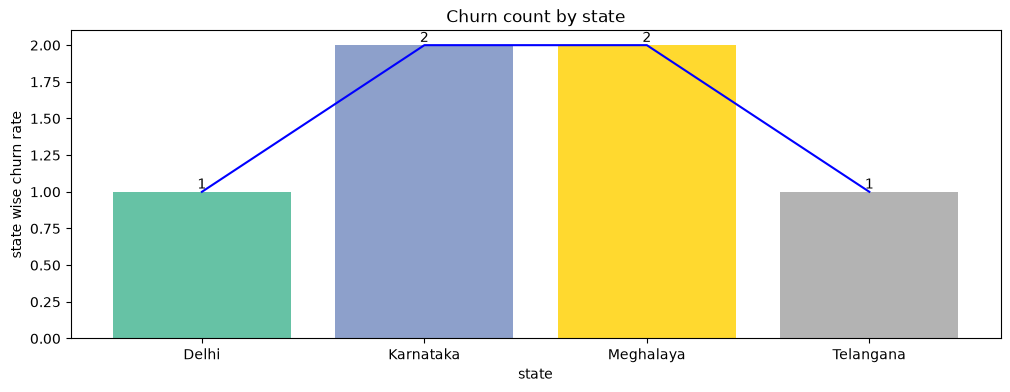

In [148]:
#churn count by state

churn_count_by_state=df_visual[df_visual['churn_flag']==1].groupby(df_visual['state']).size()

colors=plt.cm.Set2(np.linspace(0,1,len(churn_count_by_state)))


plt.figure(figsize=(12,4))
plt.plot(churn_count_by_state.index,churn_count_by_state.values,color='blue')
bar=plt.bar(churn_count_by_state.index,churn_count_by_state.values,color=colors)
plt.title('Churn count by state')
plt.xlabel('state')
plt.ylabel('state wise churn rate')

plt.bar_label(bar)

plt.show()


In [149]:
df_visual[df_visual['churn_flag']==1].groupby(df_visual['state']).size()

state
Delhi        1
Karnataka    2
Meghalaya    2
Telangana    1
dtype: int64

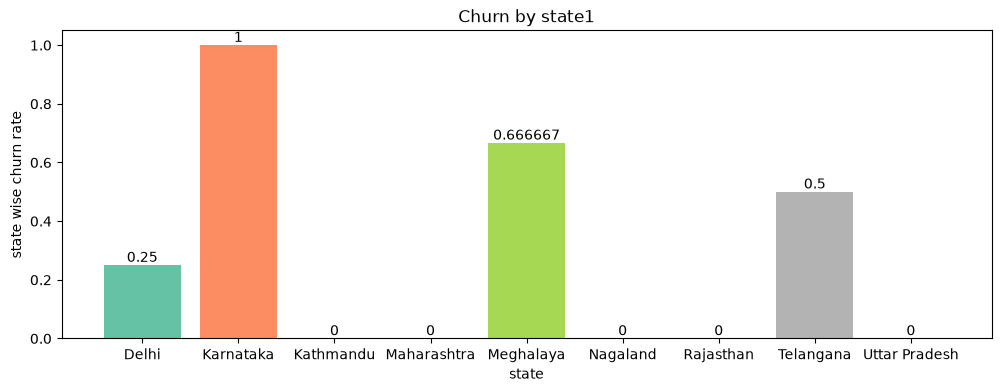

In [150]:
#churn by state

#churn_by_state=df_visual[df_visual['churn_flag']==1].groupby(df_visual['state']).size()

churn_by_state1=df_visual.groupby('state')['churn_flag'].mean()

colors=plt.cm.Set2(np.linspace(0,1,len(churn_by_state1)))


plt.figure(figsize=(12,4))
#plt.plot(churn_by_state1.index,churn_by_state1.values,color='blue')
bar=plt.bar(churn_by_state1.index,churn_by_state1.values,color=colors)
plt.title('Churn by state1')
plt.xlabel('state')
plt.ylabel('state wise churn rate')

plt.bar_label(bar)

plt.show()

In [151]:
#Seaborn


In [152]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'age',
       'active_customer', 'tenure_days', 'Escalation', 'churn_risk',
       'cancellation_month', 'cancellation_week'],
      dtype='str')

In [153]:
df_visual[['subscription_type',
       'plan_type', 'contract_type', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag',  'country', 'state', 'gender',
       'complaint_date', 'escalations', 'csat_score', 'active_customer', 'tenure_days', 'Escalation', 'churn_risk']].head()

,subscription_type,plan_type,contract_type,monthly_charges,cltv,churn_score,churn_flag,country,state,gender,complaint_date,escalations,csat_score,active_customer,tenure_days,Escalation,churn_risk
0,Refferal,Standard,Annual,13.99,627,12,0,India,Maharashtra,Male,NaT,NaN,NaN,1,1992.0,0,low
1,Paid,Premium,Annual,12.99,1150,91,1,India,Karnataka,Male,2024-08-28,Y,10.0,0,1501.0,1,high
2,Organic,Basic,Monthly,6.99,210,34,0,India,Delhi,Female,NaT,NaN,NaN,1,1377.0,0,low
3,Paid,Premium,Annual,22.99,1725,8,0,India,Nagaland,Male,NaT,NaN,NaN,1,2667.0,0,low
4,Refferal,Standard,Monthly,13.99,195,88,1,India,Delhi,Female,2024-01-20,Y,20.0,0,419.0,1,high


In [215]:
# encoding does not include right chronology/ordeed mapping of columns's category
#so the heatmap is incorrect 

# df_encoded=df_visual[['subscription_type',
#        'plan_type', 'contract_type', 'monthly_charges', 'cltv', 'churn_score',
#        'churn_flag', 'country', 'state', 'gender',
#        'complaint_date', 'escalations', 'csat_score', 'active_customer', 'tenure_days', 'Escalation', 'churn_risk']].head()

df_encoded=df_visual[[
       'plan_type', 'contract_type', 'churn_score',
       'churn_flag', 'escalations',
       'Escalation','churn_risk']].head()


categorical_cols=[
       'plan_type', 'contract_type','escalations', 'churn_risk']

for col in categorical_cols:
        df_encoded[col]= df_encoded[col].astype('category').cat.codes

In [216]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,escalations,Escalation,churn_risk
0,2,0,12,0,-1,0,1
1,1,0,91,1,0,1,0
2,0,1,34,0,-1,0,1
3,1,0,8,0,-1,0,1
4,2,1,88,1,0,1,0


<Axes: >

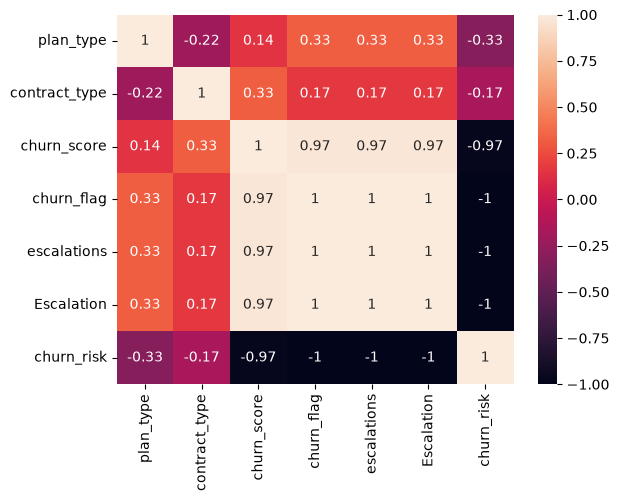

In [217]:
#heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(),annot=True)

In [218]:
df_visual['plan_type'].unique()

<StringArray>
['Standard', 'Premium', 'Basic']
Length: 3, dtype: str

In [204]:
df_visual['contract_type'].unique()

<StringArray>
['Annual', 'Monthly']
Length: 2, dtype: str

In [205]:
df_visual['churn_risk'].unique()

<StringArray>
['low', 'high', 'mdium']
Length: 3, dtype: str

In [219]:
df_encoded=df_visual[[
       'plan_type', 'contract_type', 'churn_score',
       'churn_flag','Escalation','churn_risk']].head()


order_mappings={
       'plan_type':['Basic','Standard','Premium'],
       'contract_type':['Monthly','Annual'],
       'churn_risk':['low', 'mdium', 'high']
}

for col, order in order_mappings.items():
        df_encoded[col]= pd.Categorical(df_encoded[col].astype('category'),categories=order,ordered=True).codes

In [220]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,Escalation,churn_risk
0,1,1,12,0,0,0
1,2,1,91,1,1,2
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,1,2


<Axes: >

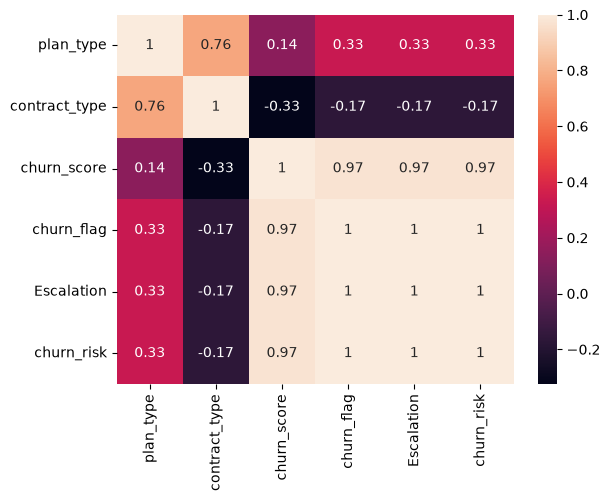

In [221]:
#heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(),annot=True)


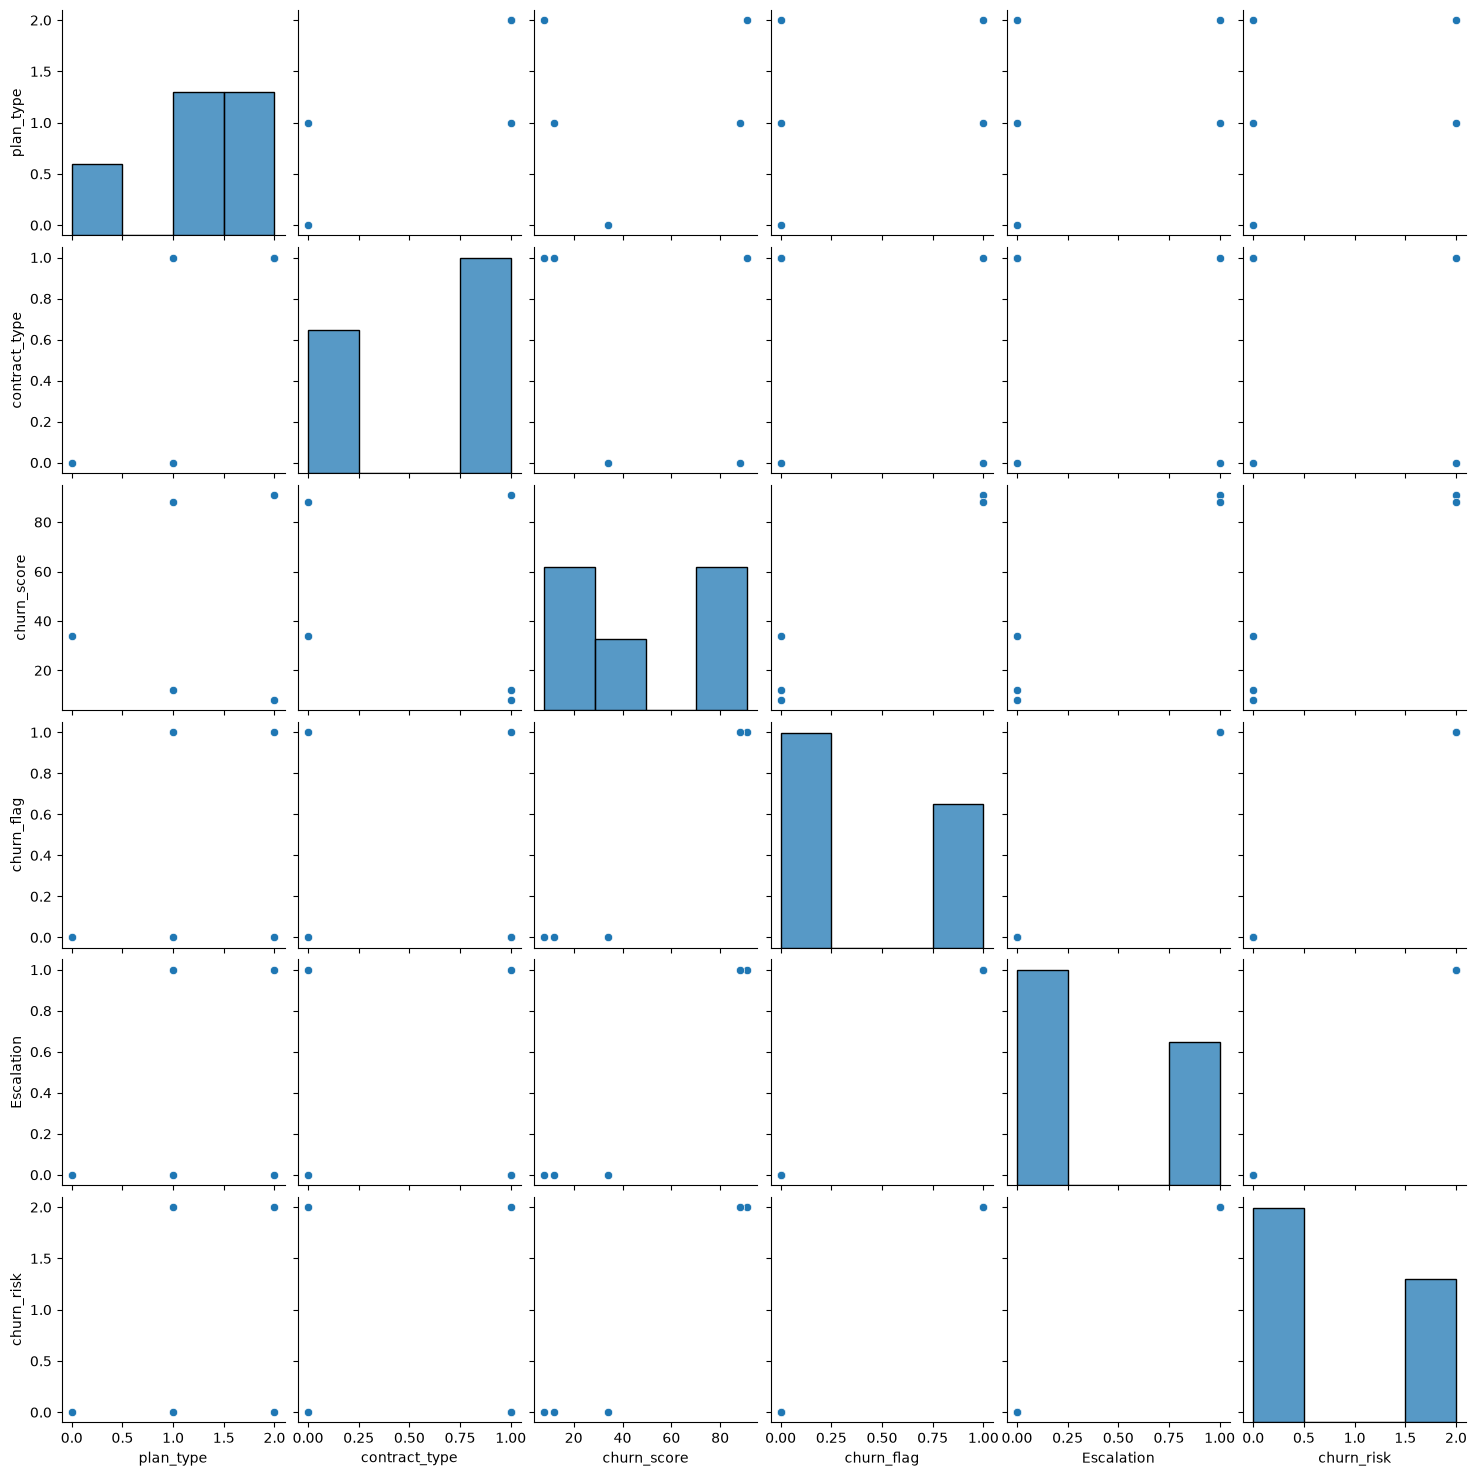

In [223]:
# pairplot -relationship in a dataset
sns.pairplot(df_encoded)

In [224]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'age',
       'active_customer', 'tenure_days', 'Escalation', 'churn_risk',
       'cancellation_month', 'cancellation_week'],
      dtype='str')

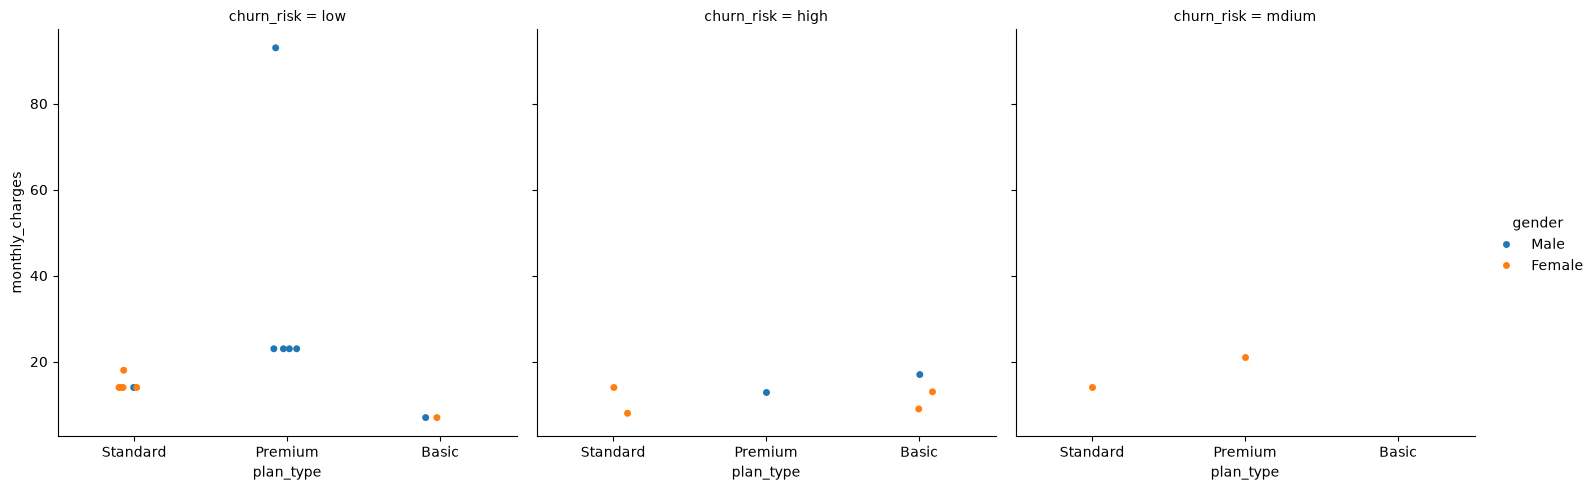

In [225]:
#catplot/facegrid plot

sns.catplot(data=df_visual,
            x='plan_type',
            y='monthly_charges',
            hue='gender',
            col='churn_risk'
            )

In [228]:
#Pivot Table

pd.pivot_table(
    df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc='mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [230]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'age',
       'active_customer', 'tenure_days', 'Escalation', 'churn_risk',
       'cancellation_month', 'cancellation_week'],
      dtype='str')

In [232]:
#Pivot Table

pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges','customerid', 'churn_flag'],
    aggfunc={
        'monthly_charges': 'sum',
        'customerid': 'nunique',
          'churn_flag': 'mean'

    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91
